# Create Arctic ocean mask

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
from matplotlib.path import Path
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyresample

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45057")
client

<Client: 'tcp://127.0.0.1:45057' processes=8 threads=32, memory=123.95 GiB>

First define Arctic Ocean domain

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

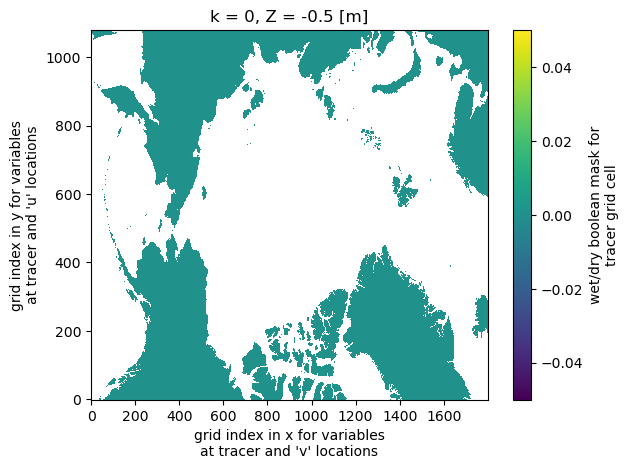

In [6]:
HH_grid_land.plot();

### Open shapefile that defines Arctic Ocean domain and then create mask

In [7]:
# load shapefile
shapefile_path = "~/efs-mount-point/mzahn/sassie/HH/Arctic_domain_mask/shapefile/Arctic_domain.shp"
shapefile = gpd.read_file(shapefile_path)

# Extract the polygon's geometry
polygon_geometry = shapefile.geometry.iloc[0]

# Ensure it's a polygon and extract boundary coordinates
if polygon_geometry.geom_type == "Polygon":
    coords = np.array(polygon_geometry.exterior.coords)
else:
    raise ValueError("The shapefile does not contain a Polygon.")

In [8]:
# Create lat/lon arrays
lon = coords[:, 0]
lat = coords[:, 1]

# Create an xarray.DataArray
polygon_coords_da = xr.DataArray(
    data=np.column_stack((lon, lat)),
    dims=["point", "coordinate"],
    coords={
        "point": np.arange(len(lon)),
        "coordinate": ["lon", "lat"]
    },
    name="polygon_coordinates"
)

# print(polygon_coords_da)

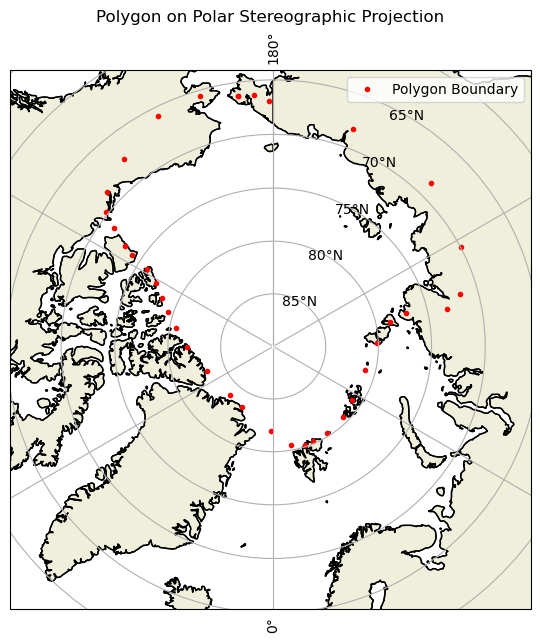

In [48]:
# Plot the points on a polar stereographic map
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()},figsize=(7, 7))

# Add features to the map
ax.add_feature(cfeature.LAND, edgecolor="black")
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree())

# Plot the polygon coordinates
ax.plot(lon, lat, marker="o", color="red", markersize=3, linestyle="", transform=ccrs.PlateCarree(),label="Polygon Boundary")

# Add labels and title
ax.set_title("Polygon on Polar Stereographic Projection")
ax.legend()

# Show the map
plt.show()

In [10]:
def get_model_equivalent_grid_cells(polygon_coords_da, grid_model):
    """
    Function that uses the lat/lon coordinates and obtains indices of the closest lat/lon points in the model dataset.
    Returns 'model_indices' which provides model i,j equivalents.
    """

    # Define lat-lon grid
    swath_model = pyresample.geometry.SwathDefinition(lons=grid_model.XC.values, lats=grid_model.YC.values)
    
    # find nearest neighbor lat/lon values from model data using in-situ lat/lon coords
    swath_pts = pyresample.geometry.SwathDefinition(lons=polygon_coords_da.sel(coordinate='lon'), lats=polygon_coords_da.sel(coordinate='lat'))
    
    # Determine nearest (w.r.t. great circle distance) neighbour in the grid.
    # Search radius is in meters. Average model grid cell is ~3.5 x 3.5 km
    _, _, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
        source_geo_def=swath_model, target_geo_def=swath_pts, radius_of_influence=10000,neighbours=1)

    index_array_filter = index_array[index_array != 1944000]
    
    # get_neighbour_info() returns indices in the flattened lat/lon grid. Compute the 2D grid indices:
    index_array_2d = np.unravel_index(index_array_filter, swath_model.shape)

    j_idx = index_array_2d[0]
    i_idx = index_array_2d[1]

    # make array that contains each [i,j] pair
    index_pairs = np.column_stack((i_idx, j_idx))
            
    # return index_array_2d
    return index_pairs

In [11]:
index_pairs = get_model_equivalent_grid_cells(polygon_coords_da, HH_grid)

In [13]:
# add one more point to fill gap (need to figure out why not all points were located properly in pyresample)
index_pairs_fill = np.vstack([index_pairs[0:-4],[600,1065],index_pairs[-4:]])

In [14]:
# pull out i and j indices
i_idx = index_pairs_fill[:, 0]
j_idx = index_pairs_fill[:, 1]

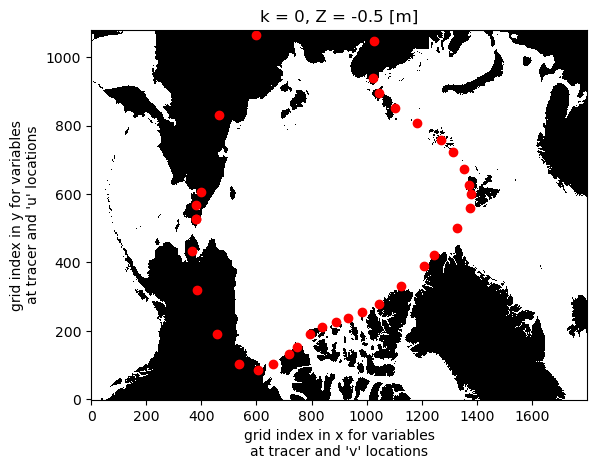

In [15]:
HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
plt.scatter(i_idx,j_idx,color='red');
# plt.scatter(600,1065,color='red')

From this source:
https://stackoverflow.com/questions/3654289/scipy-create-2d-polygon-mask

In [24]:
nx, ny = 1800, 1080
# Create vertex coordinates for each grid cell...
# (<0,0> is at the top left of the grid in this system)
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
x, y = x.flatten(), y.flatten()

points = np.vstack((x,y)).T
path = Path(index_pairs_fill)
grid = path.contains_points(points)
mask = grid.reshape((ny,nx))

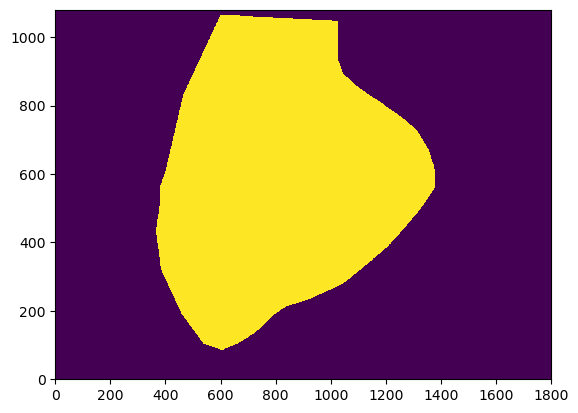

In [17]:
plt.pcolormesh(mask);

In [26]:
Depth_mask = HH_grid.Depth.where(mask)

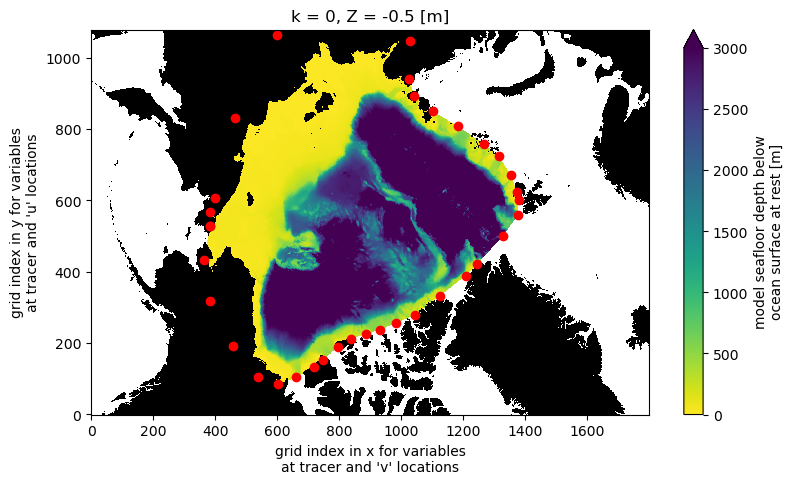

In [27]:
Depth_mask.plot(vmin=0,vmax=3000,cmap='viridis_r',figsize=[9,5])
HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
plt.scatter(i_idx,j_idx,color='red');
# plt.scatter(600,1065,color='red')

In [40]:
Arctic_ocean_mask = xr.where(mask,HH_grid.maskC,False)

In [43]:
Arctic_ocean_mask.name = "arctic_ocean_mask"

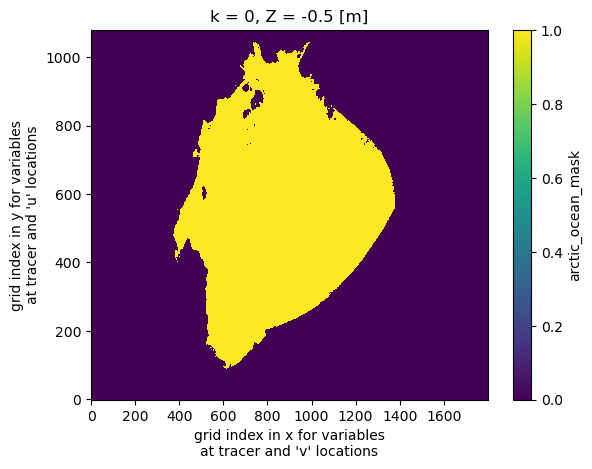

In [46]:
Arctic_ocean_mask.isel(k=00).plot();

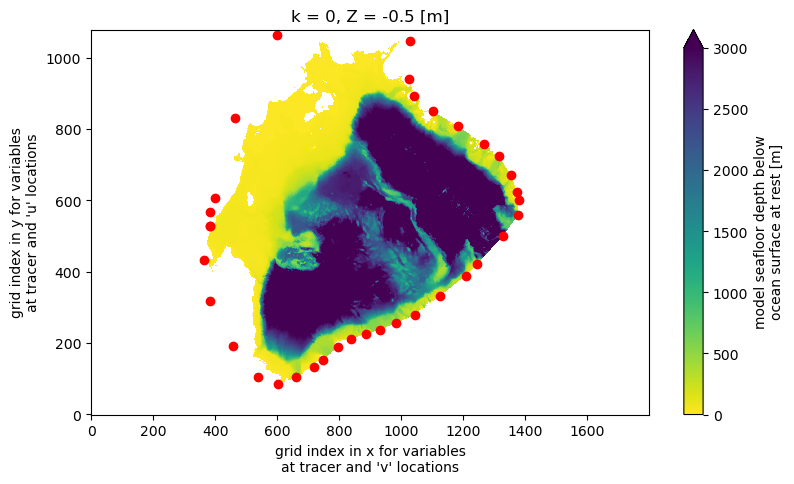

In [47]:
HH_grid.Depth.where(Arctic_ocean_mask.isel(k=0)).plot(vmin=0,vmax=3000,cmap='viridis_r',figsize=[9,5])
# HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
plt.scatter(i_idx,j_idx,color='red');
# plt.scatter(600,1065,color='red')

## Save mask to EFS

In [50]:
Arctic_ocean_mask.to_netcdf("~/efs-mount-point/mzahn/sassie/HH/Arctic_domain_mask/arctic_domain_mask.nc")

In [51]:
# open it to check
arctic_ocean_mask = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/Arctic_domain_mask/arctic_domain_mask.nc")

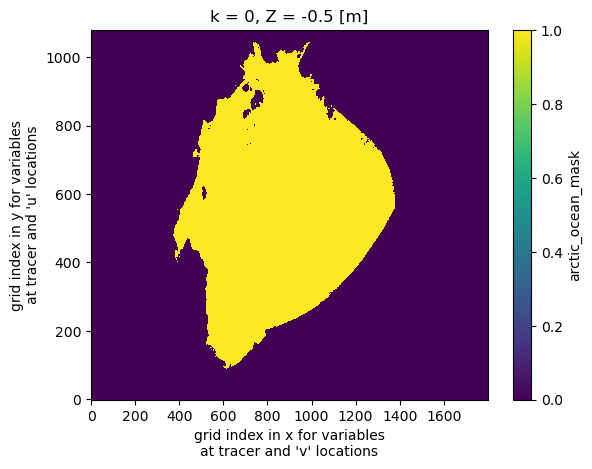

In [56]:
arctic_ocean_mask.arctic_ocean_mask.isel(k=0).plot();